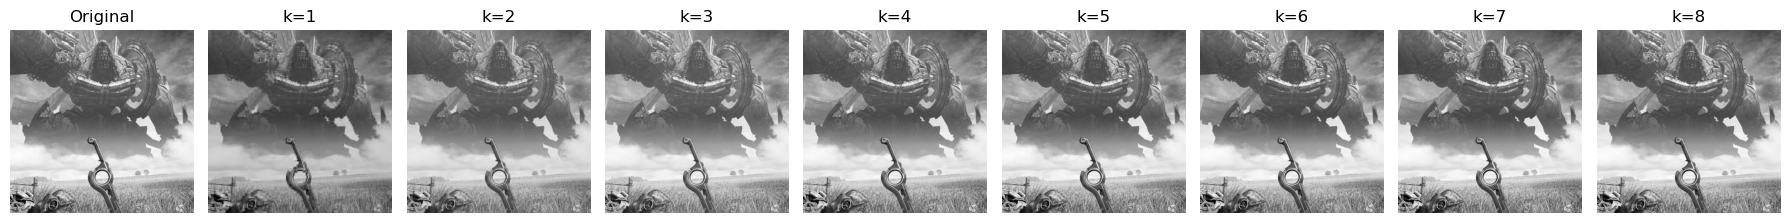

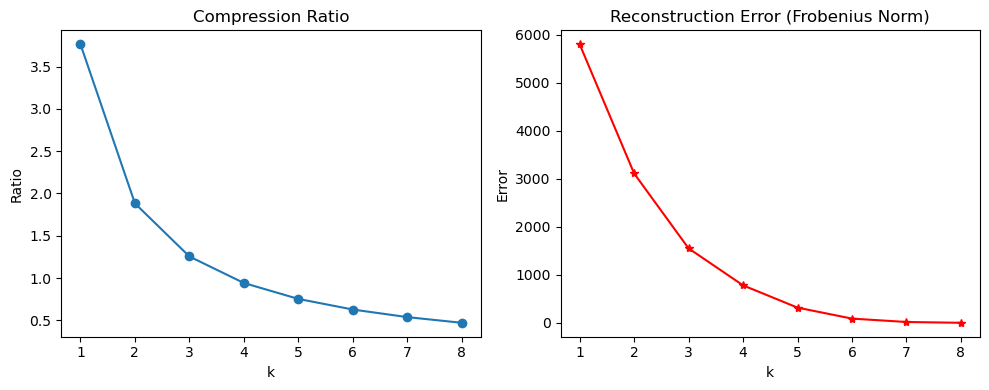

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def compress_block(block, k):
    U, S, Vt = np.linalg.svd(block, False)
    return (U[:, :k] * S[:k]) @ Vt[:k, :]

A = np.array(Image.open('monado.jpg').convert('L'), dtype=np.float64)

h, w = (np.array(A.shape) // 8) * 8
A = A[:h, :w]

k_vals = range(1, 9)
results, ratios, errors = [], [], []

for k in k_vals:
    Ak = np.zeros_like(A)
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = A[i:i+8, j:j+8]
            Ak[i:i+8, j:j+8] = compress_block(block, k)
    results.append(Ak)
    ratios.append(64 / (17 * k))
    errors.append(np.linalg.norm(A - Ak, 'fro'))

fig, ax = plt.subplots(1, 9, figsize=(18, 4))

ax[0].imshow(A, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

for idx, k in enumerate(k_vals):
    ax[idx + 1].imshow(results[idx], cmap='gray')
    ax[idx + 1].set_title(f'k={k}')
    ax[idx + 1].axis('off')

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(k_vals, ratios, 'o-')
plt.title('Compression Ratio')
plt.xlabel('k')
plt.ylabel('Ratio')

plt.subplot(1, 2, 2)
plt.plot(k_vals, errors, 'r*-')
plt.title('Reconstruction Error (Frobenius Norm)')
plt.xlabel('k')
plt.ylabel('Error')

plt.tight_layout()
plt.show()

## Execution Results
Higher k values yield sharper details and better image quality, but at the cost of a lower compression ratio. 
The rapid initial drop in Reconstruction Error followed by a plateau highlights the fundamental trade-off between 
data efficiency and visual accuracy.

## Code Description
The code compresses a grayscale image by applying SVD to 8 X 8 blocks, reconstructing them using k singular values to analyze the relationship between data reduction and visual fidelity.